# Import libs

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lendo dados

In [63]:
DATA = 'https://raw.githubusercontent.com/rafabandoni/world-cup-2026-predict/refs/heads/main/data/'

In [64]:
elo = pd.read_csv(DATA+'elo_ratings_wc2026.csv')
elo.head()

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0


In [65]:
matches_hist = pd.read_csv(DATA+'world_cup_matches.csv')
matches_hist.head()

,ID,Year,Date,Stage,Home Team,Home Goals,Away Goals,Away Team,Win Conditions,Host Team
0,1,1930,1930-07-13,Group stage,France,4,1,Mexico,NaN,False
1,2,1930,1930-07-13,Group stage,United States,3,0,Belgium,NaN,False
2,3,1930,1930-07-14,Group stage,Yugoslavia,2,1,Brazil,NaN,False
3,4,1930,1930-07-14,Group stage,Romania,3,1,Peru,NaN,False
4,5,1930,1930-07-15,Group stage,Argentina,1,0,France,NaN,False


# Análise - Base de Elos

- Cada ano representa o "end-of-year" snapshot de elo para aquela seleção;
- O ano de 2026 é ytd no salvamento da base;
- Valores máximos e mínimos são pontos históricos, não variações no ano;
- Matches e goals são agregados ano a ano;

## Atribuição e licença:
- [This Kaggle dataset](https://www.kaggle.com/datasets/afonsofernandescruz/2026-fifa-world-cup-historical-elo-ratings/data).
- The upstream source: **World Football Elo Ratings** (eloratings.net), maintained by Kirill Bukin and Erik Gebhardt continuing the work of Bob Runyan and the late Andrew Wallechinsky.

## Colunas:
| Column | Type | Description |
|---|---|---|
| `year` | int | Calendar year of the snapshot. |
| `snapshot_date` | date | `YYYY-12-31` for year-end rows; the scrape date for the live-snapshot row. |
| `country` | string | Modern team name (e.g. *Czechia*, not *Czechoslovakia*; *DR Congo*, not *Zaire*). |
| `country_code` | string | Two-letter team code as used by eloratings.net (mostly ISO 3166-1 alpha-2 but with site-specific quirks like `EN` for England, `SQ` for Scotland, `KR` for South Korea). |
| `rank` | int | Global Elo rank at the snapshot date. |
| `rating` | int | Elo rating at the snapshot date. |
| `rank_max` | int | Best (lowest-numbered) rank ever achieved by the team up to and including this snapshot. |
| `rating_max` | int | Highest Elo rating ever achieved up to this snapshot. |
| `rank_avg` | int | Career-average rank up to this snapshot. |
| `rating_avg` | int | Career-average Elo rating up to this snapshot. |
| `rank_min` | int | Worst (highest-numbered) rank ever held up to this snapshot. |
| `rating_min` | int | Lowest Elo rating ever held up to this snapshot. |
| `matches_total` | int | Cumulative full internationals played. |
| `matches_home` | int | Of `matches_total`, how many were played at home. |
| `matches_away` | int | Of `matches_total`, how many were played away. |
| `matches_neutral` | int | Of `matches_total`, how many were played at a neutral venue. |
| `wins` | int | Cumulative wins. |
| `losses` | int | Cumulative losses. |
| `draws` | int | Cumulative draws. |
| `goals_for` | int | Cumulative goals scored. |
| `goals_against` | int | Cumulative goals conceded. |
| `confederation` | string | UEFA / CONMEBOL / CONCACAF / CAF / AFC / OFC. |
| `is_host` | int | `1` if the team is hosting the tournament (USA, Canada, Mexico), else `0`. |

<Axes: >

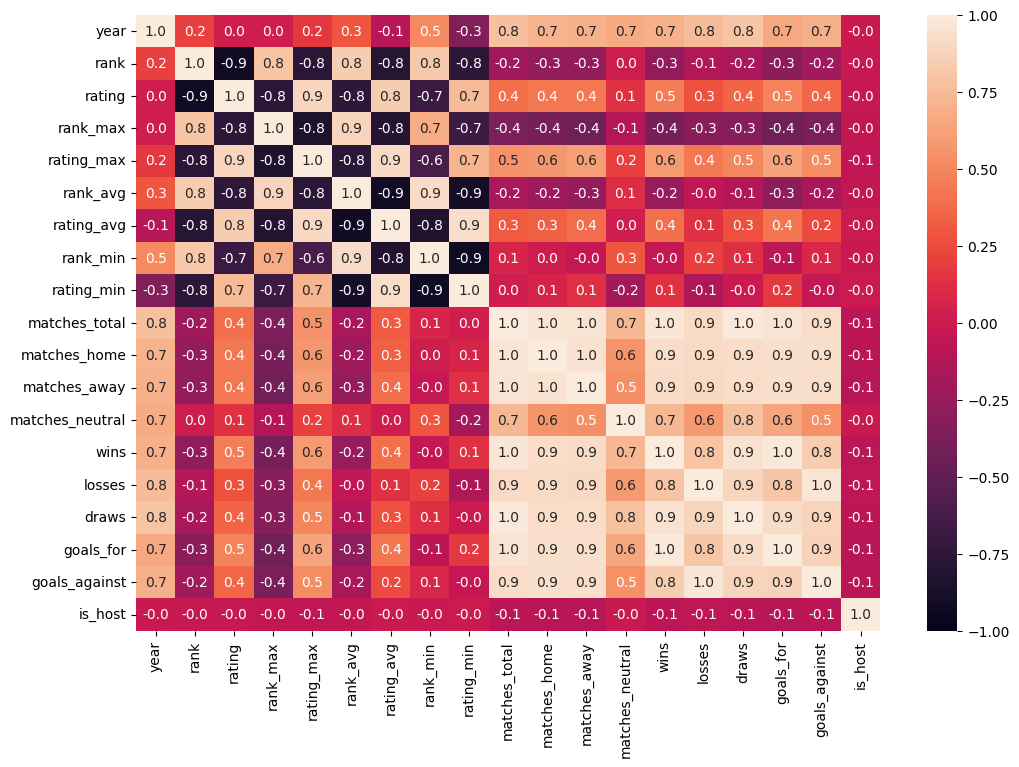

In [66]:
plt.figure(figsize=(12,8))
sns.heatmap(
    elo.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".1f"
)

In [67]:
# Não faz sentido usar todas as colunas, então vou remover algumas
elo.drop([
    ## Decidi seguir apenas com o rating, por ter mais sensibilidade que o rank - ambas tem alta correlação
    'rank',
    'rank_max',
    'rank_avg',
    'rank_min',
    ## Rating avg tbm nao adiciona mta info no rating
    'rating_avg',
    ## Home, away e neutral também não fazem diferença para a copa
    'matches_home',
    'matches_away',
    'matches_neutral',
    ## Essas outras colunas não adicionam info no dataset
    'confederation',
    'is_host',
], axis=1, inplace=True)

In [68]:
elo_br = elo[elo['country']=='Brazil']
elo_br.head()

,year,snapshot_date,country,country_code,rating,rating_max,rating_min,matches_total,wins,losses,draws,goals_for,goals_against
130,1914,1914-12-31,Brazil,BR,1910,1910,1889,2,1,1,0,1,3
144,1915,1915-12-31,Brazil,BR,1910,1910,1889,2,1,1,0,1,3
158,1916,1916-12-31,Brazil,BR,1888,1910,1873,6,2,2,2,5,7
174,1917,1917-12-31,Brazil,BR,1831,1910,1830,10,3,5,2,13,18
190,1918,1918-12-31,Brazil,BR,1831,1910,1830,10,3,5,2,13,18


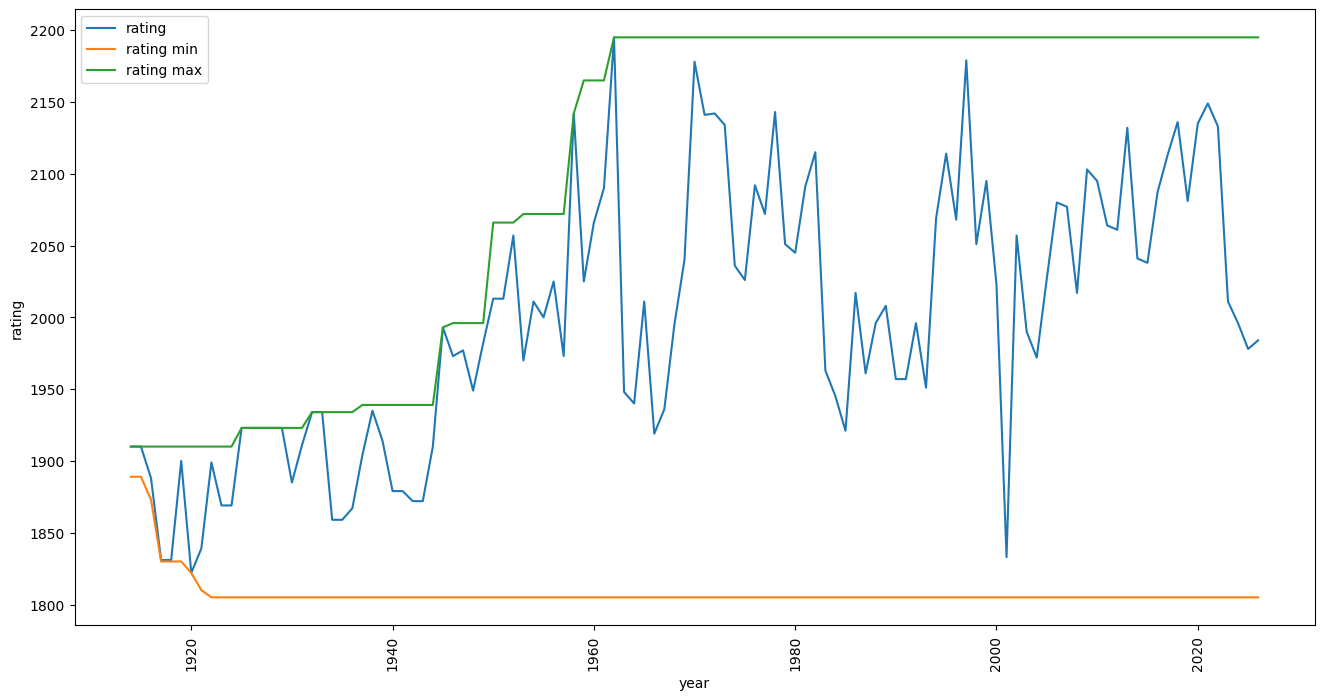

In [69]:
plt.figure(figsize=(16,8))
sns.lineplot(
    data=elo_br,
    x='year',
    y='rating',
    label='rating'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='rating_min',
    label='rating min'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='rating_max',
    label='rating max'
)
plt.legend()
plt.xticks(rotation=90)
plt.show()

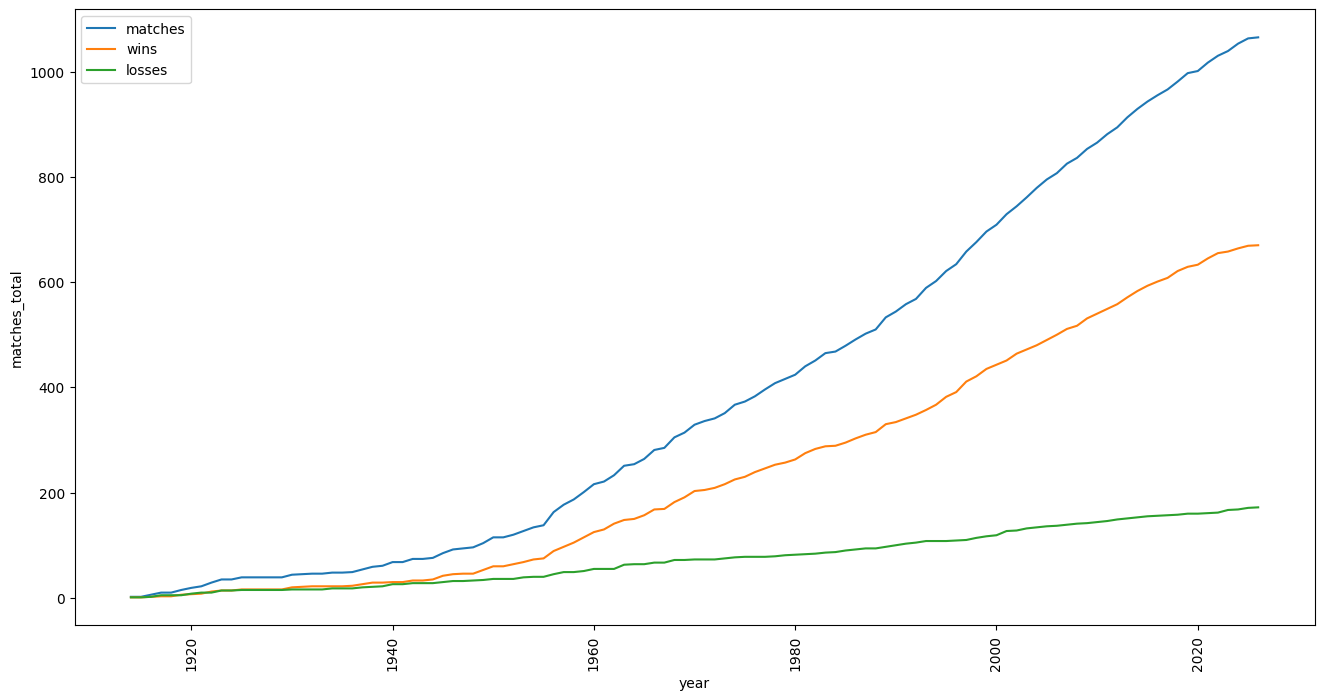

In [70]:
plt.figure(figsize=(16,8))
sns.lineplot(
    data=elo_br,
    x='year',
    y='matches_total',
    label='matches'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='wins',
    label='wins'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='losses',
    label='losses'
)
plt.legend()
plt.xticks(rotation=90)
plt.show()

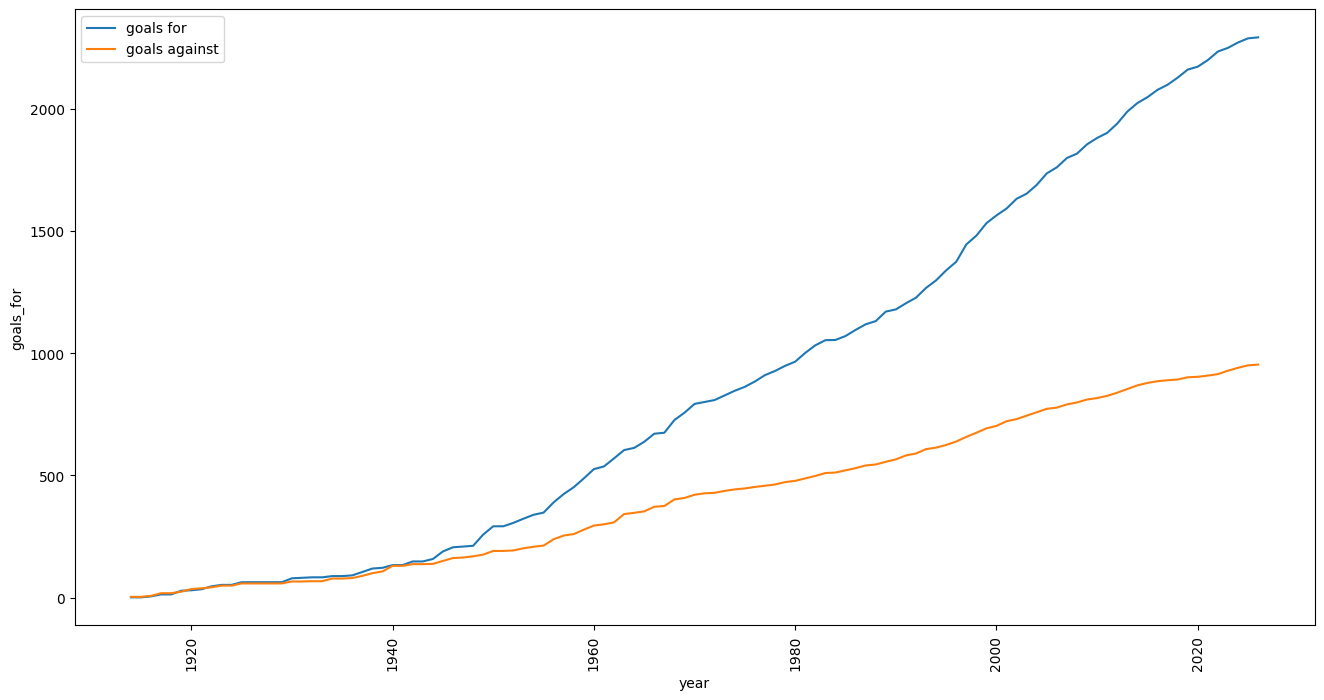

In [71]:
plt.figure(figsize=(16,8))
sns.lineplot(
    data=elo_br,
    x='year',
    y='goals_for',
    label='goals for'
)
sns.lineplot(
    data=elo_br,
    x='year',
    y='goals_against',
    label='goals against'
)
plt.legend()
plt.xticks(rotation=90)
plt.show()

## Criando base para feature engineering

In [72]:
# O elo criado no ultimo dia do ano deve ser aplicado no ano seguinte
elo = elo[elo['year'] != 2026]
elo['year_applied'] = elo['year'] + 1

# Criando valores anuais de match e goal
elo = elo.sort_values(['country_code', 'year'])
agg_cols = [
    'matches_total',
    'wins',
    'losses',
    'draws',
    'goals_for',
    'goals_against',
]

for col in agg_cols:
    elo[f'{col}_year'] = (
        elo
        .groupby('country_code')[col]
        .diff()
        .fillna(elo[col])
    )

display(elo.head())
display(elo.tail())

,year,snapshot_date,country,country_code,rating,rating_max,rating_min,matches_total,wins,losses,draws,goals_for,goals_against,year_applied,matches_total_year,wins_year,losses_year,draws_year,goals_for_year,goals_against_year
2,1902,1902-12-31,Argentina,AR,2021,2021,2021,1,1,0,0,6,0,1903,1.0,1.0,0.0,0.0,6.0,0.0
7,1903,1903-12-31,Argentina,AR,2005,2021,2005,2,1,1,0,8,3,1904,1.0,0.0,1.0,0.0,2.0,3.0
12,1904,1904-12-31,Argentina,AR,2005,2021,2005,2,1,1,0,8,3,1905,0.0,0.0,0.0,0.0,0.0,0.0
19,1905,1905-12-31,Argentina,AR,1997,2021,1997,3,1,1,1,8,3,1906,1.0,0.0,0.0,1.0,0.0,0.0
28,1906,1906-12-31,Argentina,AR,2008,2021,1980,6,3,2,1,12,5,1907,3.0,2.0,1.0,0.0,4.0,2.0


,year,snapshot_date,country,country_code,rating,rating_max,rating_min,matches_total,wins,losses,draws,goals_for,goals_against,year_applied,matches_total_year,wins_year,losses_year,draws_year,goals_for_year,goals_against_year
4387,2021,2021-12-31,South Africa,ZA,1548,1847,1448,459,202,131,126,628,487,2022,15.0,9.0,2.0,4.0,19.0,7.0
4437,2022,2022-12-31,South Africa,ZA,1540,1847,1448,469,207,133,129,641,498,2023,10.0,5.0,2.0,3.0,13.0,11.0
4487,2023,2023-12-31,South Africa,ZA,1486,1847,1448,483,213,135,135,657,511,2024,14.0,6.0,2.0,6.0,16.0,13.0
4530,2024,2024-12-31,South Africa,ZA,1576,1847,1448,504,221,136,147,690,526,2025,21.0,8.0,1.0,12.0,33.0,15.0
4582,2025,2025-12-31,South Africa,ZA,1550,1847,1448,521,231,139,151,716,537,2026,17.0,10.0,3.0,4.0,26.0,11.0
